# Notebook to perform zero-shot annotation using scLMCT foundation model

### Importing

In [ ]:

#%%
import os
# os.chdir('/data/dungp/projects/single-Cell/Sy-Code/src_LLM_CLIP')
# Environment settings
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['BLAS_NUM_THREADS'] = '1'

# import argparse

# parser = argparse.ArgumentParser()
# parser.add_argument('--device', type=str, default='3', help='GPU id to use')
# parser.add_argument('--data_dir', type=str, default='./data/zero_shot_data', help='Path to the data directory')
# parser.add_argument('--save_dir', type=str, default='./results/zero_shot_annotation', help='Path to save results')
# args = parser.parse_args()
os.environ["CUDA_VISIBLE_DEVICES"] = f"1"
import scanpy as sc
# from model_new import TrainWrapperCLIPStyle
from sclmct.model import TrainWrapperCLIPStyle

import torch
import json
import seaborn as sns
import torch.nn.functional as F
from scipy import sparse
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm


ct_to_int = json.load(open("/data/dungp/projects/single-Cell/Sy-Code/src_arcface_select_data/data/cell_type_to_int_label_encoded_0.json", 'r'))
int_to_ct = {v: k for k, v in ct_to_int.items()}

model = TrainWrapperCLIPStyle.load_from_checkpoint("./checkpoints/foundation_model/model.ckpt")


prompts_path = "/data/dungp/projects/single-Cell/Sy-Code/classification-for-publication/src_CLIP_arcface/src-semantic-embeddings/cell_type_prompt/cell_types_info_v1.json"

label_prompts = json.load(open(prompts_path, 'r'))



[INFO] Loaded model with 12 transformer layers.


### Helper functions

In [ ]:
def get_cell_type_prompts(cell_types, label_prompts=None):
    cell_type_promts = {}
    for ct in cell_types:
        if ct in label_prompts:
            cell_type_promts[ct] = label_prompts[ct]
        else:
            cell_type_promts[ct] = [f"This is a {ct} cell.",
                                    f"This cell is classified as a {ct}.",
                                    f"This is the gene expression profile of a {ct}.",
                                    f"A single-cell transcriptome from a {ct}.",
                                    f"This cell type is called {ct}.",
                                    f"Semantic annotation for this cell: {ct} cell.",
                                    f"This is a cell of type {ct}."]

    return cell_type_promts


def process_new_celltypes(cell_types, label_prompts = None):
    int_to_ct = {i: ct for i, ct in enumerate(cell_types)}

    
    model.eval()

    if label_prompts is None:
        prompt_templates = [
            "A single-cell transcriptome from a {label}.",
            "This is the gene expression profile of a {label}.",
            
            "This cell is classified as a {label}.",
            
            "This cell type is called {label}.",
            "Semantic annotation for this cell: {label} cell.",
            "This is a {label} cell.",
            "This is a cell of type {label}.",
            
            ]
        cell_types = list(int_to_ct.values())
        label_prompts = {
            i: [template.format(label=label) for template in prompt_templates]
            for i, label in enumerate(cell_types)
        }
    else:
        ## reorder the label_prompts to match the int_to_ct
        label_prompts = {i: label_prompts[ct] for i, ct in int_to_ct.items()}
        
    model.label_prompts = label_prompts

    model.prompt_token_batches = {
        class_id: model.text_encoder_wrapper.tokenizer(
            prompts,
            padding=True,
            truncation=True,
            max_length=256,  # or 512 depending on your prompt format
            return_tensors="pt"
        )
        for class_id, prompts in label_prompts.items()
    }
    ##
    os.makedirs('./cache/', exist_ok=True)
    model.on_train_start()
    # model.text_encoder_wrapper.cache_path = "./cache/temp_cache.pt"
    if os.path.exists(model.text_encoder_wrapper.cache_path):
        os.remove(model.text_encoder_wrapper.cache_path)
    model.prompt_layer10_cache = {}
    model.setup()

## extract embeddings
def extract_embeddings(adata, model, batch_size=1024):
    model.eval()
    if sparse.issparse(adata.X):
        X = adata.X.toarray()
    else:
        X = adata.X
    num_batches = X.shape[0] // batch_size + 1
    embeddings = []
    for i in range(num_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, X.shape[0])
        batch = torch.tensor(X[start:end]).float().cuda()
        with torch.no_grad():
            embedding = model(batch)
            embeddings.append(embedding.cpu())
    return torch.cat(embeddings, dim=0)


def plot_embeddings(model, adata, embeddings, int_to_ct, cell_types, label_col='cell_type', save_path=None):
    labels = []
    text_embeddings = []
    with torch.no_grad():
        for i in range(3):
            model.n_prompts = -1
            lb, t_embeddings = model.get_class_text_centers(labels = torch.LongTensor(np.arange(len(cell_types))), only_centers=True)
            labels.append(lb)
            text_embeddings.append(t_embeddings)
            
    labels = torch.cat(labels, dim=0)
    text_embeddings = torch.cat(text_embeddings, dim=0)


    text_embeddings = F.normalize(text_embeddings, dim=-1)
    labels = labels.detach().cpu().numpy()  # Convert to numpy array
    text_embeddings = text_embeddings.detach().cpu().numpy()  # Convert to numpy array

    labels = [int_to_ct[label] for label in labels]  # Map integer → cell type

    adata.obs['cell_type_ols'] = adata.obs[label_col]

    # Step 3: Filter text embeddings for those that appear in adata
    valid_labels = set(adata.obs['cell_type_ols'].unique())
    text_mask = [label in valid_labels for label in labels]
    text_embeddings = text_embeddings[text_mask]
    text_labels = [labels[i] for i, keep in enumerate(text_mask) if keep]

    # Step 4: Stack embeddings
    X_expr = embeddings
    X_text = text_embeddings
    X_stacked = np.vstack([X_expr, X_text])

    # Step 5: Add to AnnData
    adata_full = adata.copy()
    adata_full = adata_full.concatenate(
        sc.AnnData(X_text),
        batch_key="type",
        batch_categories=["cell", "text"],
        index_unique=None
    )
    adata_full.obsm["X_stacked"] = X_stacked

    # Fix labels
    cell_labels = adata.obs['cell_type_ols'].tolist()
    adata_full.obs['cell_type_plot'] = cell_labels + text_labels

    # Create a consistent color palette
    all_labels = adata_full.obs['cell_type_plot'].unique()
    palette = sns.color_palette("tab20", n_colors=len(all_labels))
    label_color_map = dict(zip(all_labels, palette))

    # Step 6: UMAP
    sc.pp.neighbors(adata_full, use_rep="X_stacked")
    sc.tl.umap(adata_full)

    # Step 7: Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    umap = adata_full.obsm["X_umap"]
    cell_mask = adata_full.obs["type"] == "cell"
    text_mask = adata_full.obs["type"] == "text"

    # Plot cells (dots) using shared color map
    sc.pl.umap(
        adata_full[cell_mask],
        color='cell_type_plot',
        palette=label_color_map,
        ax=ax,
        show=False
    )

    # Plot text embeddings (triangles) using same color map
    text_labels = adata_full.obs.loc[text_mask, 'cell_type_plot']
    for label in sorted(set(text_labels)):
        idx = (text_labels == label).values
        coords = umap[text_mask][idx]
        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            label=f"text: {label}",
            color=label_color_map[label],
            marker="^",
            edgecolor="black",
            linewidth=0.8,
            s=80
        )
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)
    plt.title("UMAP: Cells vs Text Embeddings")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


    # return the umap calculated with the obs for later plotting in R
    return adata_full



## Data Loading and Data Processing

[INFO] Generating prompt cache...
[INFO] Saved prompt cache to ./cache/cached_prompt_embeddings.pt
(4902, 768)


/tmp/ipykernel_734037/2228219870.py:121: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_full = adata_full.concatenate(
/home/dungp/miniconda3/envs/sc-python312/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dungp/miniconda3/envs/sc-python312/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dungp/miniconda3/envs/sc-python312/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


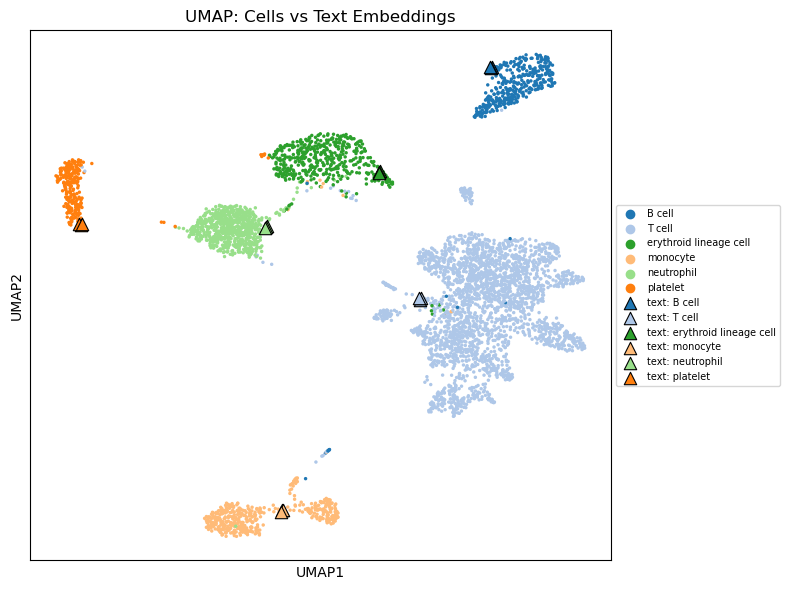

In [5]:
dts_name = "E-MTAB-9221"

label_col = 'cell_type'  

## load data
adata = sc.read(f'/data/share/dungp/single-cell/ct-classification/code4publication/code-for-reproducibility/scLMCT/data/zero_shot_data/{dts_name}.h5ad')
## data normalization if needed
if adata.X.max() > 20:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

cell_types = adata.obs[label_col].unique().tolist()

## process the cell type names 
cell_type_promts = get_cell_type_prompts(cell_types, label_prompts)
int_to_ct = {i: ct for i, ct in enumerate(cell_types)}
# process_new_celltypes(cell_types, cell_type_promts)
process_new_celltypes(cell_types)


## extract cell expression embeddings
embeddings = extract_embeddings(adata, model)
embeddings = embeddings.cpu().numpy()  # Convert to numpy array
print(embeddings.shape)
dts_save_path =   f"./results/zero_shot_annotation/{dts_name}"
if not os.path.exists(dts_save_path):
    os.makedirs(dts_save_path)

dts_save_name = dts_name.split('/')[-1]  # Get the last part of the path
## plot embeddings
adata_full = plot_embeddings(model, adata, embeddings, int_to_ct, cell_types, label_col=label_col, save_path=dts_save_path + f"/{dts_save_name}_embeddings.png")


# extract cell type text embeddings
## Get predictions  
labels = []
text_embeddings = []
with torch.no_grad():
    for i in range(10):
        model.n_prompts = 10

        lb, t_embeddings = model.get_class_text_centers(labels = torch.LongTensor(np.arange(len(cell_types))), only_centers=True)
        labels.append(lb)
        text_embeddings.append(t_embeddings)
        
labels = torch.cat(labels, dim=0)
text_embeddings = torch.cat(text_embeddings, dim=0)

text_embeddings = F.normalize(text_embeddings, dim=-1)

labels = labels.detach().cpu().numpy()  # Convert to numpy array
text_embeddings = text_embeddings.detach().cpu().numpy()  # Convert to numpy array

adata.obs['cell_type_ols'] = adata.obs[label_col]


### KNN building and predicting

In [7]:

## Train a kNN classifier on text embeddings
clf = KNeighborsClassifier(n_neighbors=5, metric='cosine', weights='distance')
clf.fit(text_embeddings, labels)


predictions = clf.predict(embeddings)
predictions = np.array([int_to_ct[label] for label in predictions])  

y_true = adata.obs['cell_type_ols'].values
y_pred = predictions
report = classification_report(y_true, y_pred, output_dict=False)
print(report)

## save predictions to a adata file
pred_adata = sc.AnnData(X=embeddings, obs=adata.obs.copy())
pred_adata.obs['predicted_cell_type'] = y_pred

## write to file
pred_adata.write_h5ad(dts_save_path + f"/{dts_save_name}_predictions.h5ad")
print(f"Predictions saved to {dts_save_path + f'/{dts_save_name}_predictions.h5ad'}")    
## save the umap and metadata
umap_df = pd.DataFrame(adata_full.obsm['X_umap'], columns=['umap1', 'umap2'])
## set index to the index of adata_full
umap_df.index = adata_full.obs.index
#  concate umap_df with the obs of adata_full, make sure the index matches
umap_df = pd.concat([umap_df, adata_full.obs], axis=1)
## save the umap and metadata to a csv file
umap_df.to_csv(dts_save_path + f"/{dts_save_name}_umap.csv", index=True)
## save the metrics to a file

with open(dts_save_path + f"/results.txt", 'w') as f:
    f.write(report)

                        precision    recall  f1-score   support

                B cell       0.44      0.88      0.59       385
                T cell       0.96      0.80      0.87      2546
erythroid lineage cell       0.91      0.98      0.94       484
              monocyte       0.81      0.68      0.74       458
            neutrophil       0.82      0.99      0.89       770
              platelet       0.98      0.71      0.83       259

              accuracy                           0.84      4902
             macro avg       0.82      0.84      0.81      4902
          weighted avg       0.88      0.84      0.85      4902

Predictions saved to ./results/zero_shot_annotation/E-MTAB-9221/E-MTAB-9221_predictions.h5ad
